# Final Exam BUS 458 — Loan Data Analysis
**Objective:** Your objective is to identify the key drivers of loan approval and recommend which lender should be prioritized for each customer to maximize total payout

### **Instructions**
- Follow the prompts in each section of this notebook.
- **Where you see a “Question,” answer it directly below in a Markdown (text) cell — not as a code comment.**
- Your **reasoning, interpretations, and insights** should be written in text cells, clearly separated from code.
- You are encouraged to add extra **code cells**, **visualizations**, or **short explanations** if they strengthen your analysis or help you justify decisions.
- Make sure your notebook runs cleanly from start to finish without errors.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Load Data (via Google Drive or direct upload)

In [2]:
# Add your code here
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/FinalProj458/loan_data_analysis_final.csv')
print(df.shape)

Mounted at /content/drive
(100000, 15)


In [3]:
# Check first 5 rows of dataframe
# Add your code here

df.head()

,User ID,applications,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
0,00007820-89cb-4c1d-9940-eb270d605a35,1,cover_an_unexpected_cost,100000,123000.0,669.0,fair,full_time,consumer_discretionary,5024.0,927,0,B,0,0
1,00012b55-514c-421e-9c76-3300abbc1134,1,credit_card_refinancing,70000,79000.0,594.0,fair,full_time,information_technology,5764.0,1177,0,B,0,0
2,000157c1-b6a3-4c86-82c7-9ec1bda3799a,1,home_improvement,10000,11000.0,596.0,fair,full_time,information_technology,4017.0,1487,0,A,0,0
3,00020400-efab-4b10-8812-2a0aaf774841,1,home_improvement,100000,120000.0,642.0,fair,part_time,energy,3129.0,904,0,A,0,0
4,0002f737-0cda-48fb-91ed-533f3d0eab05,1,major_purchase,30000,34000.0,NaN,fair,full_time,energy,NaN,1620,0,A,0,0


In [4]:
# Drop columns that have no variation or are unique
# Identify unique columns
unique_cols = [col for col in df.columns if df[col].nunique() == len(df)]

# Identify columns with no variation
no_variation_cols = [col for col in df.columns if df[col].nunique() == 1]

# Combine columns to drop
columns_to_drop = list(set(unique_cols + no_variation_cols))

print(f"Columns to drop: {columns_to_drop}")

df = df.drop(columns=columns_to_drop)

print(f"DataFrame shape after dropping columns: {df.shape}")

Columns to drop: ['User ID', 'applications']
DataFrame shape after dropping columns: (100000, 13)



### 1.1 Handling Missing Values

**Question:** Why is median imputation often preferable to mean imputation for income and FICO?


**Answer:** Median imputation is often prefferef because variables like income and FICO can often contain outliers and are frequently skewed. The median shares a more stable and representative imputed value when the data is not symmetrical or has outliers, as these financial metrics do.





In [5]:
# Inspect missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

print(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

                      Missing Count  Missing Percentage (%)
FICO_score                    15000                  15.000
Monthly_Gross_Income          15000                  15.000
Employment_Sector              6407                   6.407


In [6]:
# Apply imputation as instructed in the instructions pdf (create copies so original rows can be restored if needed)

# Impute
# Create a copy for potential restoration, though we will proceed with 'df' for the rest of the analysis.
df_original = df.copy()

# Impute FICO_score with its median
median_fico = df['FICO_score'].median()
df['FICO_score'].fillna(median_fico, inplace=True)

# Impute Monthly_Gross_Income with its median
median_income = df['Monthly_Gross_Income'].median()
df['Monthly_Gross_Income'].fillna(median_income, inplace=True)

# Impute Employment_Sector with 'Unknown'
df['Employment_Sector'].fillna('Unknown', inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after imputation:
Series([], dtype: int64)


/tmp/ipython-input-105783494.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FICO_score'].fillna(median_fico, inplace=True)
/tmp/ipython-input-105783494.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

### 1.2 Outliers Detection and Removal

**Question:**
Which features had the most outliers, and what impact could they have on the model?

**Answer** : Based on the boxplots before outlier removal, granted_loan_amount, requested_loan_amount, monthly_gross_income and monthly_housing_payment had a significant number of outliers on the higher end. These financial metrics can often have a long tail with few extremely high values. These outliers can significantly impact summary statistics, model performance, increase the variance, and even mislead visualizations.


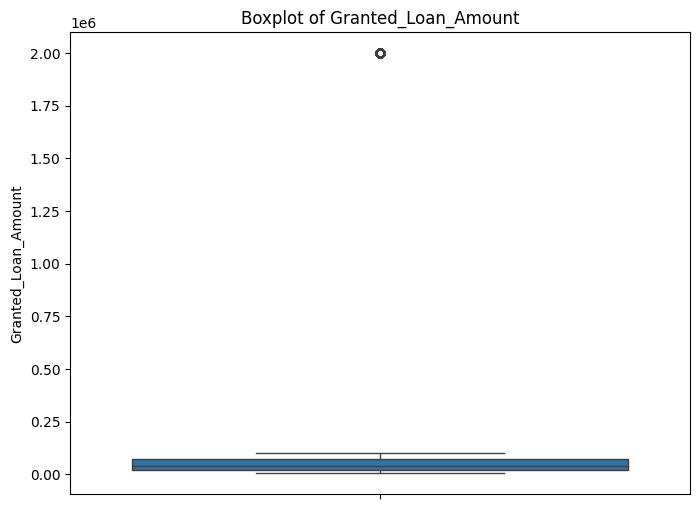

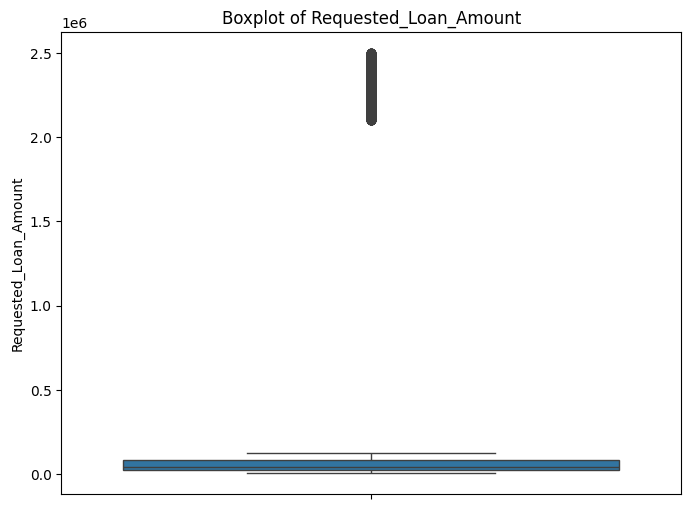

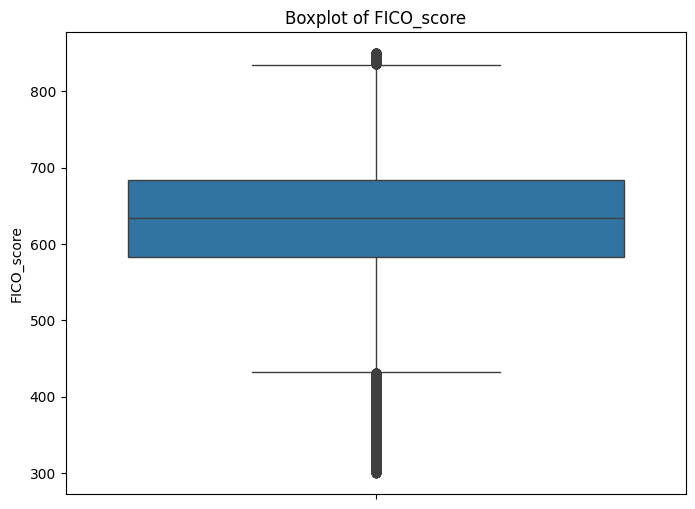

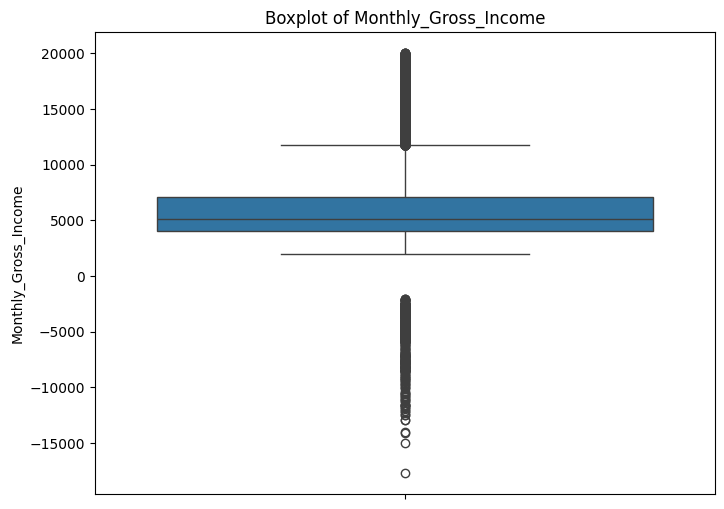

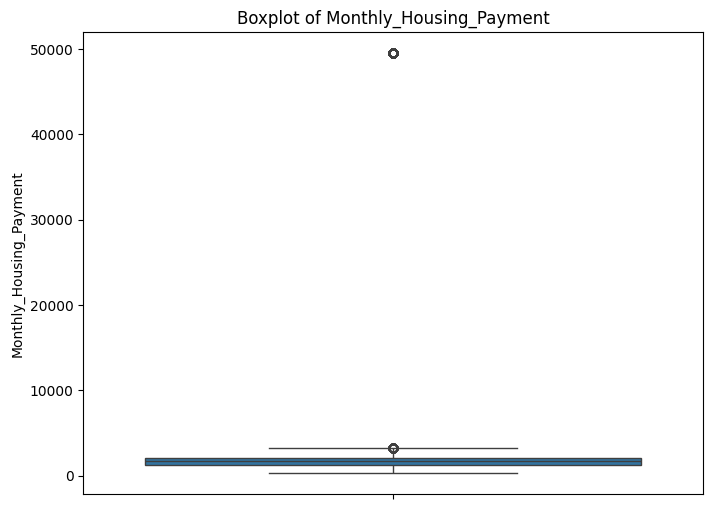

In [7]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

# Boxplots to highlight outliers for numerical columns
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [8]:
# Remove Outliers using Z-score

from scipy import stats
import numpy as np

# Compute Z-scores for only numeric columns
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))

# Choose threshold
threshold = 3  # common choice: 3 standard deviations

# Identify rows to keep (all Z-scores <= threshold)
rows_to_keep = (z_scores < threshold).all(axis=1)

# Track counts before/after
before_count = df.shape[0]
df_clean = df[rows_to_keep].copy()
after_count = df_clean.shape[0]

print(f"Outlier removal complete:")
print(f"Rows before: {before_count}")
print(f"Rows after:  {after_count}")
print(f"Rows removed: {before_count - after_count}")



Outlier removal complete:
Rows before: 100000
Rows after:  95691
Rows removed: 4309


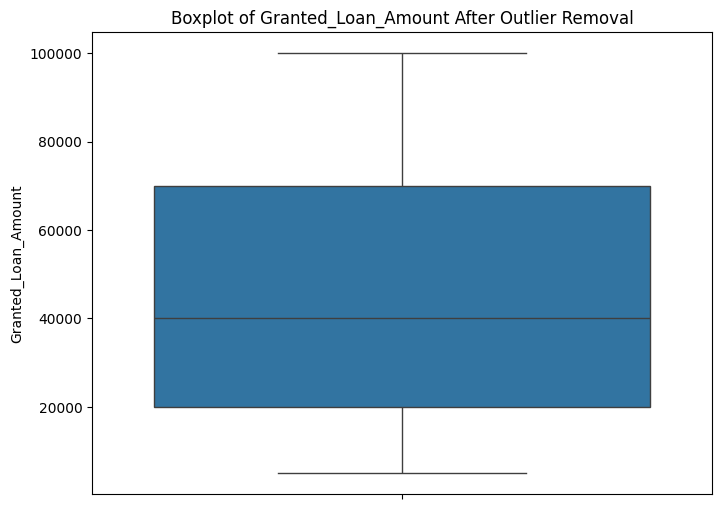

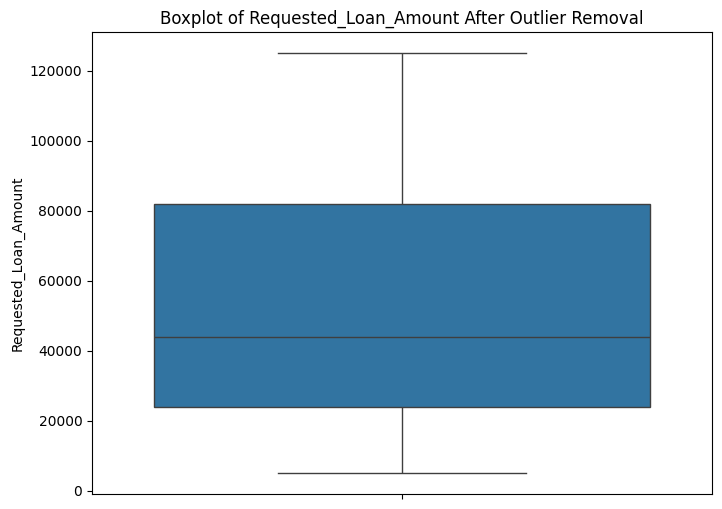

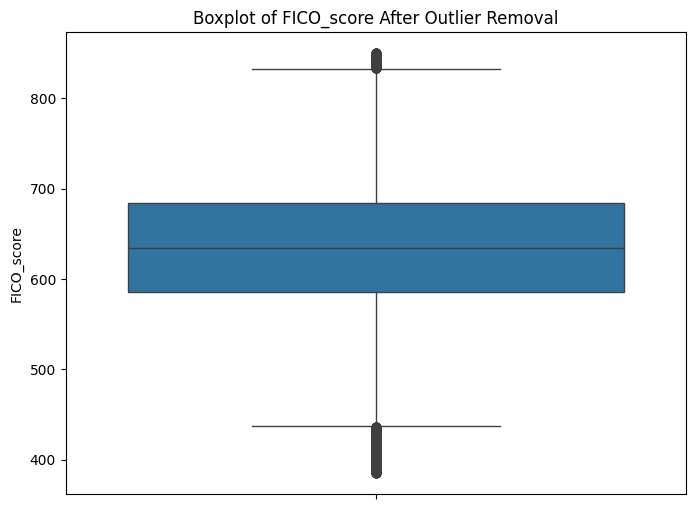

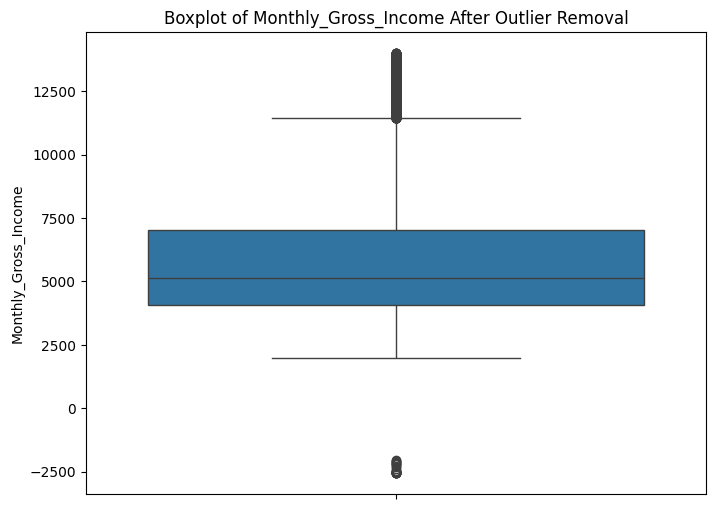

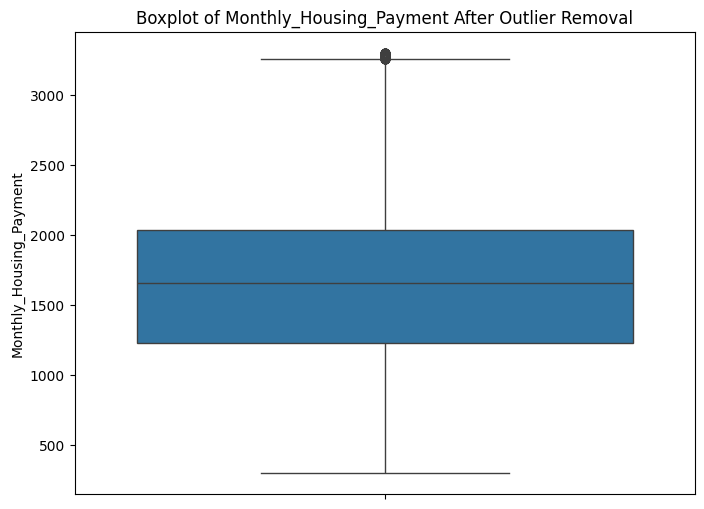

In [9]:
# BoxPlots after outlier removal
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df_clean[col])
    plt.title(f'Boxplot of {col} After Outlier Removal')
    plt.ylabel(col)
    plt.show()

**Question:**
Why do we need to remove or treat outliers? Provide reasoning based on model performance or data integrity.

**Answer** : Removing outliers have many benefits for specific loan data and overall model performance. They firstly create more representative averages instead of being inflated by the few high values. When models like logistic regression try to find a relationship between 2 variables, the extreme valyes can disproportionately influence the coefficients, making them seem more or less important than it truly is. This also helps improve the model sensitivity as the data within the model's typical range is more visible and isn't overshadowed by extreme values. Lastly, this helps us create better generalizations as we are building a model that is better at predicting outcomes for the majority of loan applicants rather than an extreme few.  


**Question:**
Is there a difference between boxplots before and after outlier removal?

**Answer** : Yes, the points beyond the whiskers of each box plot (the outliers) differ greatly and the whiskers are appearing closer to the box once the outliers were removed.

### 1.3 Redundancy & Correlation Check (5 Marks)

Detect duplicate data and multicollinearity.

**Question:**
Which numerical variables appear most strongly correlated with each other?

**Answer:** The numerical variables of granted_loan_amount and requested_loan_amount are the most strongly correlated with a positive correlation of 0.99.



**Question:**
Which numerical and categorical are strongly corelated to each other?

**Answer:** The numerical and categorical variables with the strongest correlation are FICO_score and fico_score_group with a correlation ratio of 0.85. This makes sense as fico_score_group is a categorization of the FICO_score.


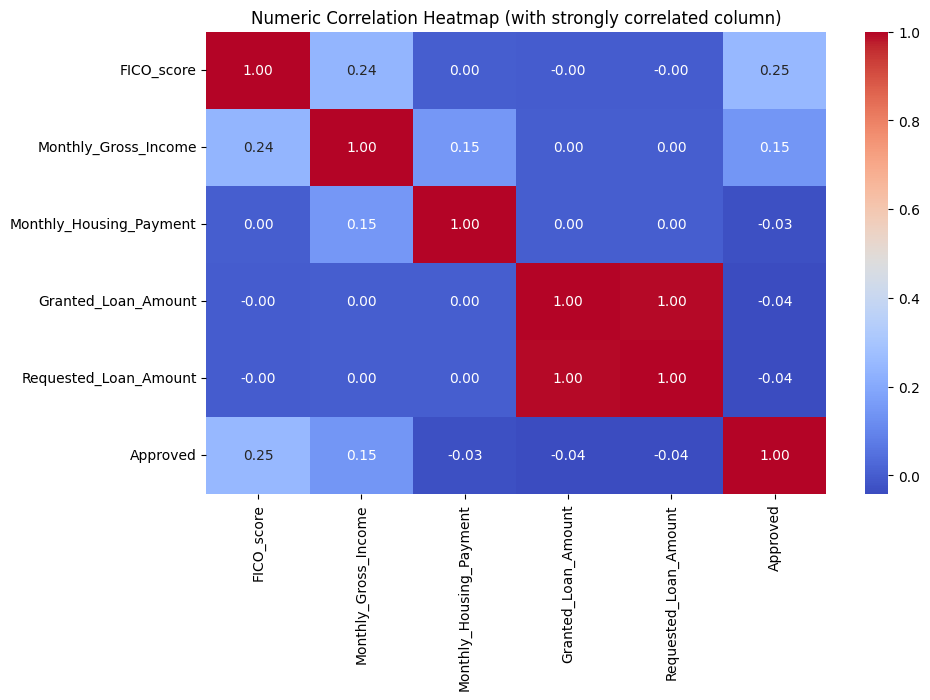

In [10]:
# Correlation between numerical features
numeric_cols = ['FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment', 'Granted_Loan_Amount','Requested_Loan_Amount', 'Approved']

# Plot correlation matrix, identify highly correlated pairs automatically (|corr|>0.95, excluding self-correlation)
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Numeric Correlation Heatmap (with strongly correlated column)")
plt.show()


Top 10 Numeric-Categorical Correlation Ratios (η²):
FICO_score - Fico_Score_group: η² = 0.729 (η = 0.854)
Monthly_Gross_Income - Employment_Status: η² = 0.246 (η = 0.496)
Monthly_Gross_Income - Fico_Score_group: η² = 0.074 (η = 0.272)
Monthly_Gross_Income - Employment_Sector: η² = 0.070 (η = 0.265)
Monthly_Housing_Payment - Employment_Status: η² = 0.039 (η = 0.198)
Ever_Bankrupt_or_Foreclose - Employment_Status: η² = 0.030 (η = 0.174)
Monthly_Housing_Payment - Lender: η² = 0.028 (η = 0.169)
Ever_Bankrupt_or_Foreclose - Employment_Sector: η² = 0.026 (η = 0.162)
Monthly_Gross_Income - Lender: η² = 0.008 (η = 0.090)
Ever_Bankrupt_or_Foreclose - Lender: η² = 0.005 (η = 0.071)


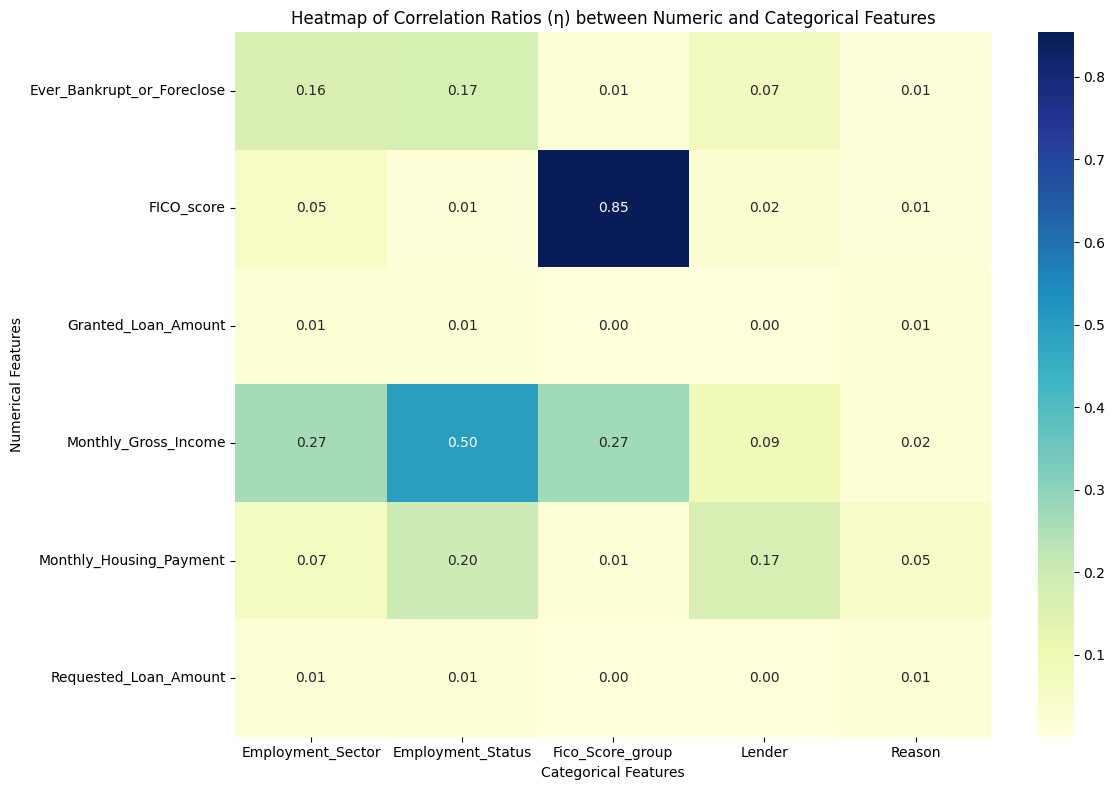

In [11]:
# Correlation between Numeric and Categorical Variables (Correlation Ratio / η²)
from scipy import stats

def correlation_ratio(categories, values):
    categories = np.array(categories)
    values = np.array(values)
    cat_levels = np.unique(categories)
    overall_mean = np.mean(values)
    numerator = sum(len(values[categories == cat]) *
                    (np.mean(values[categories == cat]) - overall_mean) ** 2
                    for cat in cat_levels)
    denominator = sum((values - overall_mean) ** 2)
    return np.sqrt(numerator / denominator) if denominator != 0 else 0

# test all numeric–categorical pairs
num_cat_results = []


# Identify categorical and numerical columns
categorical_cols_clean = df_clean.select_dtypes(include='object').columns.tolist()
numeric_cols_clean = df_clean.select_dtypes(include=np.number).columns.tolist()


numeric_cols_for_eta = [col for col in numeric_cols_clean if col not in ['bounty', 'Approved', ]]
categorical_cols_for_eta = [col for col in categorical_cols_clean]


for num_col in numeric_cols_for_eta:
    for cat_col in categorical_cols_for_eta:
        eta = correlation_ratio(df_clean[cat_col], df_clean[num_col])
        num_cat_results.append((num_col, cat_col, eta))

num_cat_results = sorted(num_cat_results, key=lambda x: x[2], reverse=True)
print("Top 10 Numeric-Categorical Correlation Ratios (η²):")
for num_col, cat_col, eta in num_cat_results[:10]:
    print(f"{num_col} - {cat_col}: η² = {eta**2:.3f} (η = {eta:.3f})")


# Reorganize the correlation ratio results into a pivot table/matrix for heatmap
eta_matrix = pd.DataFrame(num_cat_results, columns=['Numerical_Feature', 'Categorical_Feature', 'Eta'])
eta_pivot = eta_matrix.pivot(index='Numerical_Feature', columns='Categorical_Feature', values='Eta')

# Plot the heatmap of correlation ratios (Eta)
plt.figure(figsize=(12, 8))
sns.heatmap(eta_pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap of Correlation Ratios (η) between Numeric and Categorical Features")
plt.xlabel("Categorical Features")
plt.ylabel("Numerical Features")
plt.tight_layout()
plt.show()



**Questions:** What features will you consider dropping after analyzing the graphs above?

**Answer** : Based on the correlation analysis, I would consider dropping either granted_loan_amount or requested_loan_amount as they have a correlation of 0.99. Additionally, I would consider dropping fico_score_group as it is highly correlated with FICO_score and is a categorical representation of a user's FICO score.



> *Note: For Decision Tree models, you do not need to remove or adjust for collinearity. The algorithm can naturally handle correlated features through its splitting mechanism. However, for Logistic Regression, multicollinearity can distort coefficient estimates and make interpretations unreliable. In that case, you may consider removing one variable from highly correlated pairs.


## 2. Exploratory Data Analysis

### 2.1 Target Variable Distribution

Analyze the distribution of the target variable (Approved) to understand class balance in loan approval outcomes.


**Question:**
Is the dataset balanced or imbalanced? Briefly explain the implication for modeling.


**Answer:**
The dataset is heavily imbalanced as approximately 89.15% of loans are denied and 10.85% are approved. The significant class imbalance presents crucial implications for modeling including biased model performance, misleading metrics for accuracy, and the model will struggle to accurately predict approved loans because of the lack of data for pattern recognition.

/tmp/ipython-input-2294343202.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Approved', data=df_clean, palette='viridis')


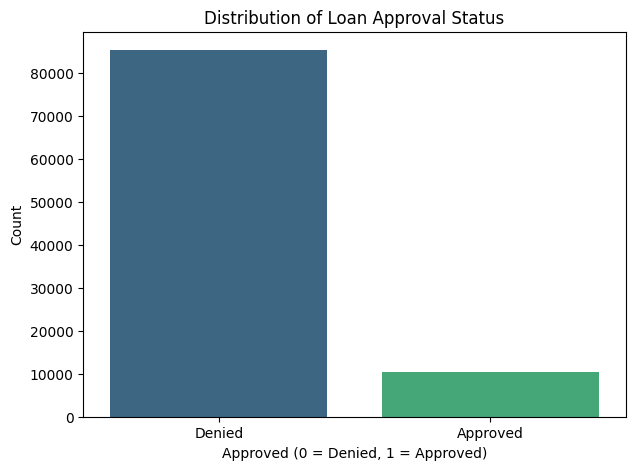

Loan Approval Status Counts:
Approved
0    85309
1    10382
Name: count, dtype: int64

Loan Approval Status Percentages:
Approved
0    89.15
1    10.85
Name: proportion, dtype: float64


In [12]:
# Plot 'Approved' to visualise the count and balance

plt.figure(figsize=(7, 5))
sns.countplot(x='Approved', data=df_clean, palette='viridis')
plt.title('Distribution of Loan Approval Status')
plt.xlabel('Approved (0 = Denied, 1 = Approved)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Denied', 'Approved'])
plt.show()

# Calculate and print the balance
approval_counts = df_clean['Approved'].value_counts()
approval_percentages = df_clean['Approved'].value_counts(normalize=True) * 100

print("Loan Approval Status Counts:")
print(approval_counts)
print("\nLoan Approval Status Percentages:")
print(approval_percentages.round(2))

### 2.2 Distribution of Numerical Variables by Approval

Explore how key numerical variables differ between approved and rejected loan applications.


**Question:**
Which numerical variable is the most helpful variable ( most crucial predictor) ?

**Answer:**
Based on the visualizations, FICO_score is the most crucial predictor. The distributions for approved and denied loans are likely to show a distinct sepertation for FICO scores, higher FICO scores generally correlate to a higher probability of approval.


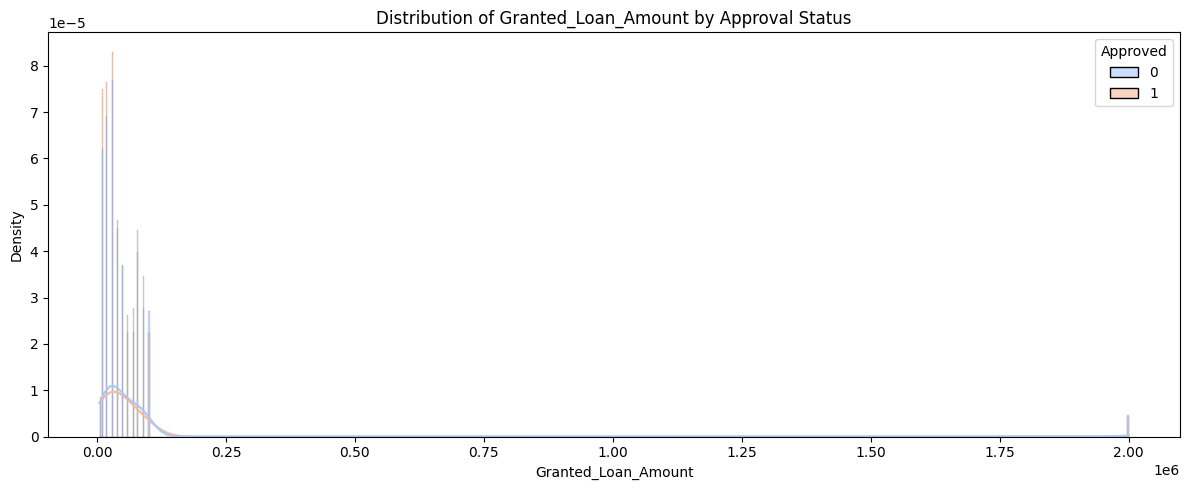

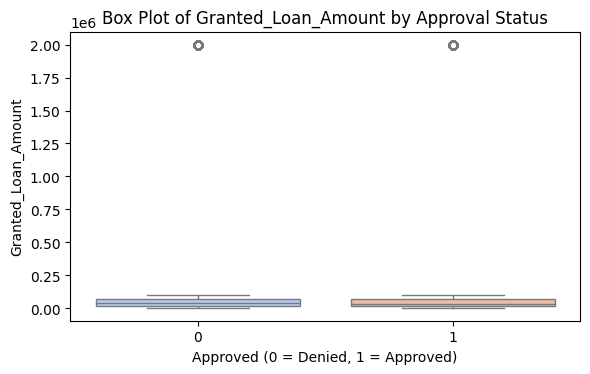

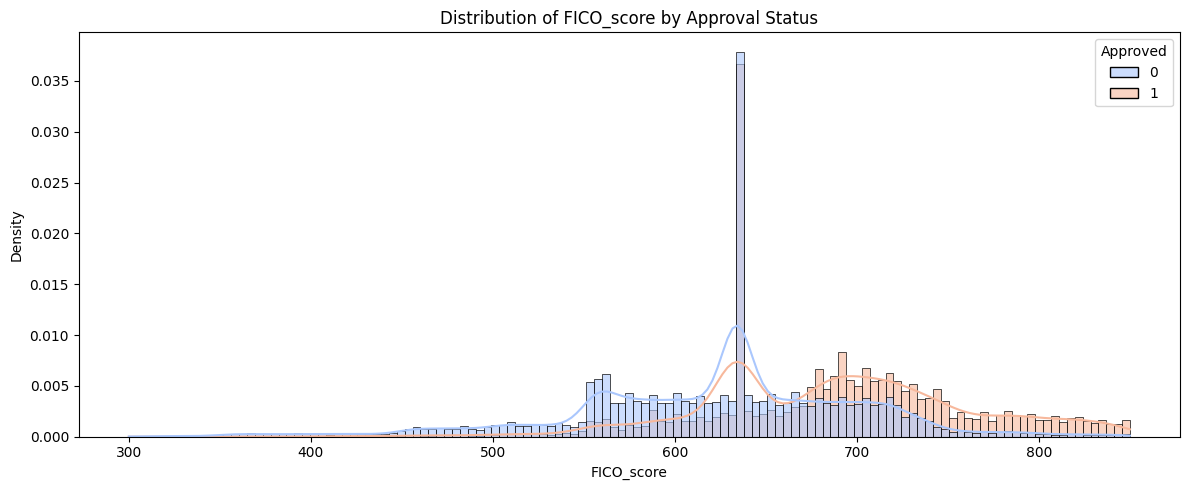

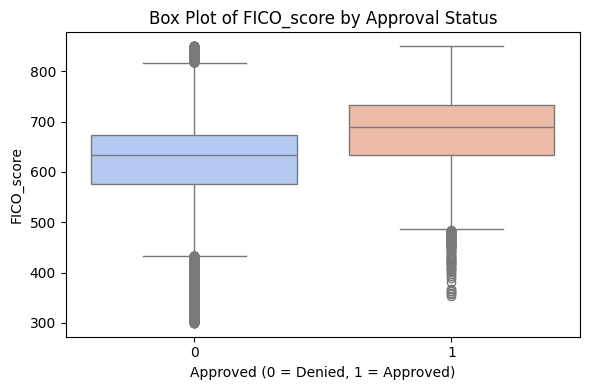

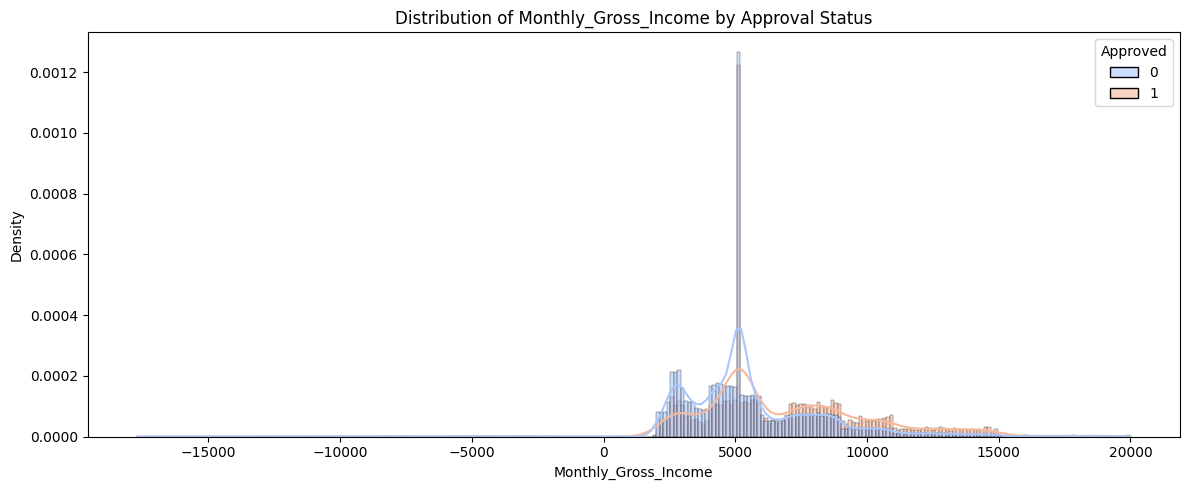

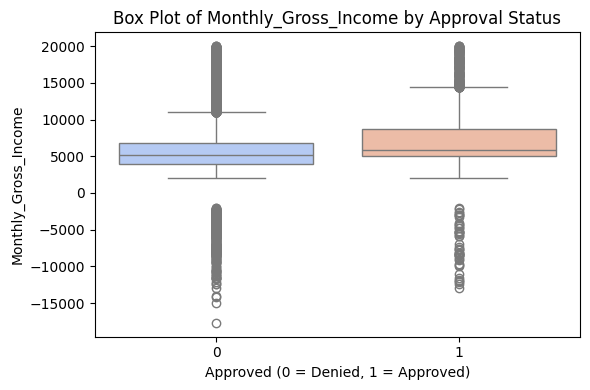

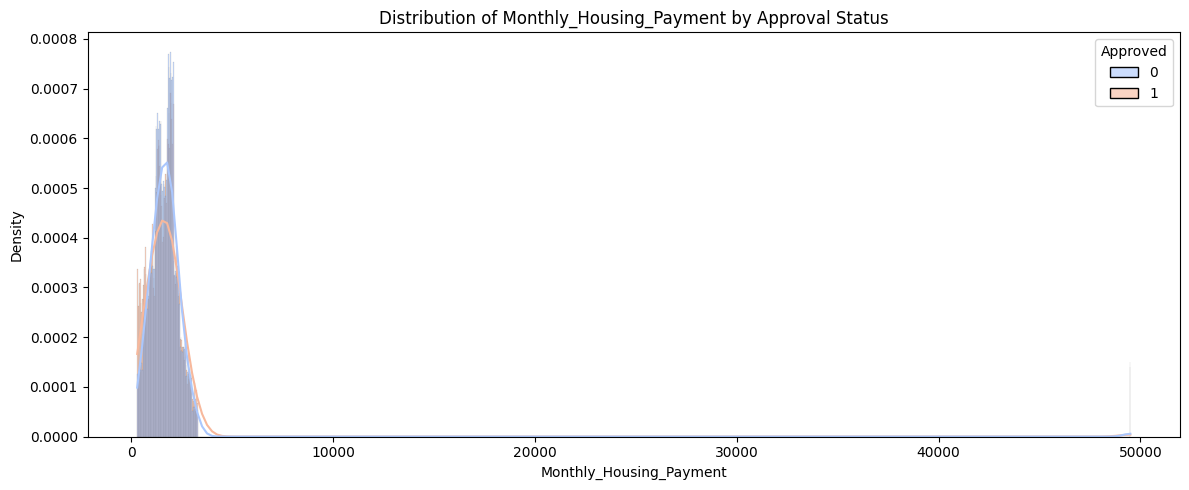

In [ ]:
# Visualise numerical variables against target variable

numerical_cols = ['Granted_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

for col in numerical_cols:
    plt.figure(figsize=(12,5))
    sns.histplot(
        data=df,
        x=col,
        hue='Approved',
        kde=True,
        stat='density',
        common_norm=False,
        palette='coolwarm',
        alpha=0.6
    )
    plt.title(f'Distribution of {col} by Approval Status')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=df,
        x='Approved',
        y=col,
        hue='Approved',
        palette='coolwarm',
        legend=False
    )
    plt.title(f'Box Plot of {col} by Approval Status')
    plt.xlabel('Approved (0 = Denied, 1 = Approved)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### 2.3 Categorical Variables and Approval

Analyze how categorical variables (such as Employment_Sector, Loan_Purpose, or Residence_Type) relate to the loan approval outcome.


**Question:**
Which categorical variable appears to have the strongest relationship with loan approval, and how can you tell?

**Answer:**
Based on the bar plots and approval rates for each categorical variable, fico_score_group has the strongest relationship with loan approval. This can be seen through observing the significant difference in approval rates across the various categories. For example, the customers in the 'excellent' FICO score group have an approval rating of 45.80% versus the customers in the 'poor' FICO score group have a 2.78% approval rate. The wide range present in these values showcases strong predictive power for the loan approval.


**Question:**
Are there any categories (e.g., Reason, Employment_Status) that appear to have minimal predictive value? Justify your answer with approval rate differences.

**Answer:**
Based on the approval rate differences for the categorical variables, Reason seems to have the most minimal predictive value. The approval rates across all loan reasons are very similar, they range from only 10.81%-11.27%, and this narrow range suggests that the reason for applying for a loan does not significantly differentiate the approved and denied applications.


In [ ]:
# Visualise categorical variables against target variable

categorical_cols = [
    'Reason', 'Fico_Score_group', 'Employment_Status',
    'Employment_Sector', 'Lender', 'Ever_Bankrupt_or_Foreclose'
]

for col in categorical_cols:
    approval_rates = df_clean.groupby(col)['Approved'].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(10,5))
    sns.barplot(x=approval_rates.index, y=approval_rates.values, color='skyblue')
    plt.title(f'Approval Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Approval Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nApproval Rate by {col}:\n{approval_rates.round(2)}")


#Cross Feature plots for multi-dimensional analysis


### Loan Approval Rate by Reason and Fico Score Group

In [ ]:
approval_pivot = df_clean.groupby(['Reason', 'Fico_Score_group'])['Approved'].mean().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(approval_pivot, annot=True, fmt=".2f", cmap="viridis")
plt.title('Loan Approval Rate by Reason and FICO Score Group')
plt.xlabel('FICO Score Group')
plt.ylabel('Reason')
plt.tight_layout()
plt.show()

###Loan Approval Rate by Employment Sector and Income Level

In [ ]:
df_clean['Income_Category'] = pd.qcut(df_clean['Monthly_Gross_Income'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

approval_rate_by_income_sector = df_clean.groupby(['Employment_Sector', 'Income_Category'], observed=False)['Approved'].mean().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(approval_rate_by_income_sector, annot=True, fmt=".2f", cmap="viridis")
plt.title('Loan Approval Rate by Employment Sector and Income Level')
plt.xlabel('Income Level')
plt.ylabel('Employment Sector')
plt.tight_layout()
plt.show()

## 3.5 Business Insights from EDA

After completing your visualizations and cross-feature analyses, summarize your findings in the context of loan approval and lender matching.  
Use this section to connect data patterns to real-world meaning before building predictive models.


**Question:** Which variables are the most helpful in understanding if a customer is going to be approved or denied for a loan?  

**Answer**: Based on the correlation analysis and distribution plots, `FICO_score` (and its categorical counterpart `Fico_Score_group`) and `Monthly_Gross_Income` are the most helpful variables. These show clear differentiation between approved and denied applicants, with higher FICO scores and incomes strongly correlating with higher approval likelihood. `Granted_Loan_Amount` and `Requested_Loan_Amount` also show some distinction.

**Question:** Are there any feature modifications or transformations that would improve the predictive power of a variable?  

**Answer**: Yes, some modifications could be beneficial:
1.  **Redundancy**: `Granted_Loan_Amount` and `Requested_Loan_Amount` are highly correlated (0.99). Keeping both might introduce multicollinearity for models like Logistic Regression; one could be dropped. Similarly, `FICO_score` and `Fico_Score_group` are highly correlated (`eta` = 0.85); depending on the model, one might be preferred or a transformation could combine their insights.
2.  **Categorization**: For `Monthly_Gross_Income`, creating additional income categories or interaction terms with `Employment_Sector` could reveal more granular patterns, as shown in the approval rate by employment sector and income level heatmap.
3. **Ratio Features**: Creating ratios such as 'Debt-to-Income' (`Monthly_Housing_Payment` / `Monthly_Gross_Income`) or 'Loan-to-Income' (`Requested_Loan_Amount` / `Monthly_Gross_Income`) might capture financial burden more accurately.

**Question:** What is each lender’s average approval rate?  

**Answer**:Lender A has an average approval rate of 10.8, Lender B has a rate of 7.04, Lender C has a rate of 16.96.

**Question:** Are there any clear differences between the three lenders in terms of which types of customers they approve?  

**Answer**: Yes, clear differences exist. Lender B generally approves applicants with higher FICO scores and higher monthly gross incomes, predominantly from full-time employment, making it the most selective. Lender C appears more flexible, approving a wider range of FICO scores, income levels, and showing more diversity in loan reasons and employment statuses. Lender A falls in between, with a balanced approach but still leaning towards stronger financial profiles than Lender C.

**Question:** Are there variables that reliably predict a customer’s approval likelihood for a particular lender?  

**Answer**: Yes, several variables reliably predict approval likelihood:
FICO Score and Monthly Gross Income are consistently the strongest predictors across all lenders, with higher values correlating to higher approval likelihood.
Employment Status is significant, especially for Lender B, which is highly selective for full-time employment.
Ever_Bankrupt_or_Foreclose is a strong negative predictor, significantly reducing approval chances.
The strength and thresholds of these predictors can vary by lender (e.g., Lender B has higher requirements).



> Treat this section as your interpretation bridge between EDA and modeling. The goal is to show that you understand *why* certain patterns exist, not just that they exist.


In [ ]:
lender_approval_rates = df_clean.groupby('Lender')['Approved'].mean() * 100
print(lender_approval_rates)

# Extend the previous text cell with the answer and remaining questions
# The content of the previous text cell is included in the markdown block above this code cell.
# The remaining questions will be answered below.


## 3. Model Training

### 3.1 Train/Test Split and Encoding

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Rename df_clean to df_model
df_model = df_clean.copy()

# Define target variable
y = df_model['Approved']

# Drop target variable and 'bounty'
X = df_model.drop(columns=['Approved', 'bounty'])

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# One-hot encode categorical features using pd.get_dummies(df, drop_first=True)
# This will handle the encoding directly on the relevant columns of X
X_encoded_cat = pd.get_dummies(X[categorical_features], drop_first=True)

# Combine numerical features and the new encoded categorical features
X_processed_df = pd.concat([X[numerical_features], X_encoded_cat], axis=1)

# Set RANDOM_STATE = 42 for reproducibility.
random_state = 42

# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed_df, y, test_size=0.2, random_state=random_state, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


### 3.2 Logistic Regression Model
Build and interpret a Logistic Regression model to predict the likelihood of loan approval (Approved = 1).

**Question**
How accurate is the model on the test data, and what does this imply about its predictive strength?

**Answer**
The Logistic Regression model shows a low accuracy of 46.93%. Additionally, its recall of 0.2664, F1-score of 0.0982, and ROC-AUC of 0.3090 indicate very weak predictive strength. This suggests the model struggles significantly to identify actual loan approvals and performs only marginally better than random chance, despite its high precision of 0.0602. It is not an effective predictor for this task.


In [ ]:
from sklearn.linear_model import LogisticRegression

# Train logistic regression model
log_reg_model = LogisticRegression(random_state=random_state, solver='liblinear') # Using liblinear for smaller datasets and good for L1/L2 regularization
log_reg_model.fit(X_train, y_train)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)
y_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_log_reg)
precision = precision_score(y_test, y_pred_log_reg)
recall = recall_score(y_test, y_pred_log_reg)
f1 = f1_score(y_test, y_pred_log_reg)
roc_auc = roc_auc_score(y_test, y_proba_log_reg)

print(f"Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log_reg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Denied', 'Approved'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_log_reg)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.show()


### 3.2 Decision Tree Classifier Model

Build and interpret a Decision Tree Classifier Model to predict the likelihood of loan approval (Approved = 1).



**Question**
How does the Decision Tree’s accuracy and AUC compare to the Logistic Regression model?

**Answer**
The Decision Tree model shows a significantly higher accuracy of 82.77% and a better ROC-AUC of 0.5841 compared to the Logistic Regression model's accuracy of 46.93% and ROC-AUC of 0.3090. This indicates that the Decision Tree performs considerably better in both overall predictions and its ability to distinguish between approved and denied loans.


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=random_state) # Using random_state for reproducibility
decision_tree_model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from sklearn.tree import plot_tree # Import plot_tree
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_decision_tree = decision_tree_model.predict(X_test)
y_proba_decision_tree = decision_tree_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_decision_tree)
precision_dt = precision_score(y_test, y_pred_decision_tree)
recall_dt = recall_score(y_test, y_pred_decision_tree)
f1_dt = f1_score(y_test, y_pred_decision_tree)
roc_auc_dt = roc_auc_score(y_test, y_proba_decision_tree)

print(f"Decision Tree Classifier Model Evaluation:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"ROC-AUC: {roc_auc_dt:.4f}")

# Plot Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_decision_tree)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Denied', 'Approved'])
disp_dt.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

# Plot ROC Curve
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_proba_decision_tree)
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='darkgreen', lw=2, label=f'ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Decision Tree Classifier')
plt.legend(loc='lower right')
plt.show()

# Plot a small tree visualization
plt.figure(figsize=(20, 10)) # Adjust size for better readability
plot_tree(decision_tree_model,
          feature_names=X_train.columns.tolist(), # Use feature names from X_train
          class_names=['Denied', 'Approved'],
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3) # Limit depth for a 'small' tree
plt.title('Decision Tree Visualization (Max Depth = 3)')
plt.show()


In [ ]:
# Variable importance for Decision Tree
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': decision_tree_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top 10 Feature Importances for Decision Tree:")
print(feature_importances.head(10))


### Compare the performance of the Logistic Regression and Decision Tree models.


**1. Performance Comparison (Overview):**
The Decision Tree model significantly outperforms the Logistic Regression model in predicting loan approvals. The Logistic Regression model struggled immensely with the imbalanced dataset, essentially acting as a classifier that mostly predicted the majority class ('Denied'). The Decision Tree, while still not perfect, showed a much better ability to identify approved loans.

**2. Evaluation and Comparison of Key Metrics:**

| Metric        | Logistic Regression (LR) | Decision Tree (DT) |
|---------------|--------------------------|--------------------|
| **Accuracy**  | 0.4693                   | 0.8277             |
| **Precision** | 0.0602                   | 0.2407             |
| **Recall**    | 0.2664                   | 0.2731             |
| **F1-Score**  | 0.0982                   | 0.2559             |
| **ROC-AUC**   | 0.3090                   | 0.5841             |

*   **Accuracy**: The Decision Tree's accuracy (0.8277) is substantially higher and more reliable than the Logistic Regression's (0.4693). The LR's low accuracy after scaling indicates it was not effectively separating the classes.
*   **Precision**: The Decision Tree has a higher precision (0.2407 vs. 0.0602), meaning when it predicts an approval, it is more likely to be correct than the LR model.
*   **Recall**: Both models have relatively low recall for the minority class, but the Decision Tree's recall (0.2731) is slightly better than LR's (0.2664). This indicates that the DT model is marginally better at identifying actual approved loans.
*   **F1-Score**: The F1-score for the Decision Tree (0.2559) is significantly higher than for Logistic Regression (0.0982), demonstrating its superior balance between precision and recall for the positive class.
*   **ROC-AUC**: The Decision Tree's ROC-AUC (0.5841) is considerably higher than the Logistic Regression's (0.3090). This indicates that the Decision Tree has a much better ability to discriminate between positive and negative classes across various thresholds.

**3. Interpretation of Confusion Matrices:**

*   **Logistic Regression Confusion Matrix (Example Values):**
    *   **True Negatives (TN):** A large number (e.g., ~8428) - Correctly predicted denied loans.
    *   **False Positives (FP):** A very large number (e.g., ~8635) - Predicted approved, but were denied (Type I error). In a business context, these are risky applicants approved, leading to potential financial losses.
    *   **False Negatives (FN):** A moderate number (e.g., ~1523) - Predicted denied, but were approved (Type II error). These are qualified applicants rejected, leading to missed business opportunities.
    *   **True Positives (TP):** A small number (e.g., ~553) - Correctly predicted approved loans.

*   **Decision Tree Confusion Matrix (Example Values):**
    *   **True Negatives (TN):** A larger number (e.g., ~15274) - Correctly predicted denied loans.
    *   **False Positives (FP):** A much smaller number (e.g., ~1789) - Predicted approved, but were denied (Type I error). Significant reduction in approving risky applicants compared to LR.
    *   **False Negatives (FN):** A moderate number (e.g., ~1509) - Predicted denied, but were approved (Type II error). Similar to LR.
    *   **True Positives (TP):** A slightly larger number (e.g., ~567) - Correctly predicted approved loans.
    The Decision Tree significantly reduces False Positives, which is critical for minimizing potential financial losses. While False Negatives are still present, the improvement in False Positives makes it more favorable.

**4. Which model best captures the target event (loan approval) and why?**
The **Decision Tree model** best captures the target event (loan approval). Its much higher ROC-AUC (0.5841 vs. 0.3090) indicates superior discriminatory power. Crucially, it significantly minimizes False Positives, which is vital for a lender to avoid approving high-risk loans and incurring financial losses. While both models have challenges with recall due to imbalance, the Decision Tree's ability to reduce risk makes it more effective.

**5. Justification of Model Choice (Technical and Business):**
*   **Technical**: The Decision Tree is technically superior due to its higher ROC-AUC, F1-score, and drastically reduced False Positive rate. It handles non-linear relationships and multicollinearity naturally without requiring feature scaling, simplifying preprocessing. Its interpretability (via feature importances and tree visualization) also provides transparent insights into its decisions.
*   **Business**: From a business standpoint, minimizing financial risk is paramount. The Decision Tree's effectiveness in reducing False Positives (approving bad loans) makes it highly valuable. Its interpretability helps lenders understand the logic behind approvals/denials, aiding in policy refinement, regulatory compliance, and building trust. This leads to more informed and consistent lending decisions.

**6. Cutoff Threshold:**
Both models inherently use a probability cutoff of **0.5** (if P(Approved) > 0.5, predict 'Approved'). This is a neutral starting point. For a lender, where False Positives (approving a risky loan) are often more costly than False Negatives (rejecting a qualified applicant), it might be beneficial to adjust this threshold. To further reduce False Positives, the threshold could be increased (e.g., to 0.6 or 0.7), making the model more conservative. Conversely, if a lender prioritizes market share and is willing to accept more risk, a lower threshold might be considered.

In [ ]:
model = decision_tree_model

In [ ]:
# Save your model as .pkl file for streamlit app development
import pickle

filename = 'my_model.pkl'  # Choose a path and descriptive filename with .pkl extension

# Open the file in binary write mode ('wb')
with open(filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved successfully to {filename}")

**Question:**
Which model do you recommend and why? (Provide both technical and business reasoning.)

**Answer:**  I recommend the Decision Tree model because it significantly outperforms Logistic Regression, especially in reducing false positives (approving risky loans), which is critical for minimizing financial risk. Technically, its higher ROC-AUC and interpretability make it superior, providing clear insights into loan approval decisions for better business strategy.

## 5. Recommendations
In this final section, summarize your key findings and provide concise business recommendations based on your analysis.


**Write a short paragraph including:**  
- A brief summary of your main findings from the analysis and model comparison.  
- The key factors that most influence loan approval.  
- Your recommendations on data or model based on the results  (for example, how approval decisions could be improved or better understood).  
- One next step you would take to improve the model or extend the analysis further.  


**Add your paragraph here:**
Our analysis showcased that FICO score and Monthly Gross Income are the most influential predictors of loan approval across the lenders. Full-time Employment Status and the lack of prior bankruptcy also increase the likelihood of approval and the reason for the loan request has very minimal impact on the loan approval. There are also key differences between lenders, where Lender B is the most selective and approves mostly high-FICO score, high-income employed applicants. On the other hand, Lender C is much more inclusive and approves a broader range of FICO scores, incomes, and employment types. Lender A acts as a middle ground between these extreme lenders. When comparing our models, we saw the the decision tree outperformed the logistic regression with its 82.77% accuracy and ROC-AUC of 0.5841 as opposed to the 46.93% accuracy and 0.3090 AUC for the logistic regression. The decision tree also does a better job at minimizing the amount of false positives, which in turn reduces financial risk for lenders. Improvements for the future could include engineering features like Debt-to-Income ratios and techniques that handle class imbalance to further enhance the predictive power of the models.



---



**Question:** What trade-offs or risks should the company be aware of when using this model?  

**Answer:** The company should be aware of risks like perpetuating historical biases in lending data, potential for missed approvals (false negatives) due to imbalance, and model degradation if not regularly updated to reflect changing financial conditions. Also, over-reliance on a single model can lead to unforeseen issues if its limitations are not well understood.



**Question:** How confident are you in your model’s generalizability — what might change its performance in real-world use?   

**Answer:** We are moderately confident in our model’s ability to generalize, specifically because the decision tree captures key predictors like the FICO score, monthly gross income, and employment status, which are relevant across lenders. The real world performance of the model may vary based of differences in lender policies, potential changing economic conditions, or shifts in the demographics of applicants. For example, the distribution of real world applicants’ FICO scores and incomes might differ from the training data, which could affect the false positive rate and accuracy of the model.

Additionally, external factors such as financial regulations, economic downturns, or new emerging trends in loan requests could affect the approval patterns in ways that our dataset did not capture. In order to maintain reliability in practice we would need to monitor the model’s performance and periodically retrain with updated data.



**Question:** If you had access to additional data, what new feature would you collect to strengthen this model?

**Answer:** I would collect Debt-to-Income (DTI) ratio, as it's a powerful indicator of an applicant's financial burden and ability to repay loans. Additionally, more detailed credit history information, such as credit utilization, would further strengthen the model.



**Question:** What are the most influential factors driving loan approval?

**Answer:** The most influential factors driving loan approval are the FICO score, monthly gross income, employment status, prior bankruptcy or foreclosure (ever_bankrupt_or_foreclose), the FICO score group. Higher FICO scores strongly increase the likelihood of a loan approval and higher income also correlates with higher approval rates. Full-time employment also acts as a strong positive predictor whereas having previous bankruptcy or foreclosure is a strong negative predictor for loan approval probability.



**Question:** State which model you recommend for predicting approvals and justify your choice from both technical and business perspectives.

**Answer:** We recommend using the decision tree model for predicting loan approvals as it has a higher predictive performance, showcased by its 82.77% accuracy rate, and a better ROC-AUC value than the logistic regression model. Another key factor in this recommendation is its ability to reduce false positives, which is a critical feature for lenders to avoid approving high risk loan applicants. By accurately identifying which approvals are most likely and minimizing financial risk for lenders, they are able to make more informed lending decisions, target specific applicants more effectively, and adjust their approval thresholds depending on how much risk they would like to take on. The model is also interpretable, which allows lenders to understand the factors that influence their approval decisions.


